# Diff-Image Displacement Predictor — Synthetic 20x Flake-Placement Data

Same model as `diff_pred.ipynb` (blur-diff two frames -> blank ViT -> MLP head), including the same
5-dim target `[Δx, Δy, Δcx, Δcy, Δarea]` and the same masked-loss convention — but most items are
synthesized rather than pulled from a real captured episode.

Each `Dataset` item is one of two kinds:
- **Synthetic** (probability `1 - REAL_PAIR_PROB`, default 75%): `frame_i` is a real hdf5 video
  frame, `frame_j` is a synthetic `top.jpg`-over-`bottom.jpg` composite at a random pixel offset.
  `Δx, Δy` come from that offset; `Δcx, Δcy, Δarea` come from `frame_i`'s real Newton-ring feature
  (stored in the hdf5) vs. `RING_NOT_FOUND` for `frame_j` (`top.jpg`/`bottom.jpg` carry no physical
  ring, so the synthetic composite never has one: `Δarea` is well-defined, `Δcx, Δcy` are masked out).
- **Real** (probability `REAL_PAIR_PROB`, default 25%): both `frame_i` and `frame_j` are real hdf5
  video frames from the same episode — `Δx, Δy, Δcx, Δcy, Δarea` all come from stored motor position
  and ring features, exactly mirroring `diff_pred.ipynb`'s `PairDisplacementDataset`.

Only the **20x** hdf5/video pair is used (not 5x) — `bottom.jpg`/`top.jpg` are 20x designs, so they
match `20x.mp4`'s magnification 1:1 (no downscale needed, unlike `flake_designer.py`'s 5x default).

**Per folder in `20X_DropDown/{0,1,2,3,4}/`**:
1. SIFT-align `bottom.jpg` onto that folder's own reference frame of `20x.mp4` (native resolution —
   used only for this one-time fit, for the best possible SIFT feature quality), giving a fixed
   affine transform (SIFT features computed on a blurred copy of `bottom.jpg`, used only for the fit
   — matches `flake_designer.py`). A single global reference frame doesn't fit well for every folder
   (verified against `flake_designer.py`'s own live SIFT view — e.g. folder 3 gave a degenerate,
   far-from-identity affine at frame 70 but a clean one at frame 100/50), so each folder has its own
   entry in `SIFT_FRAME_NUMS`.
2. For each synthetic sample: pick a random pixel offset `(dx, dy)` (`bottom.jpg`'s native pixel
   space) and warp both `top.jpg` and `bottom.jpg` through the fitted transform **at the video's
   native resolution** (`top.jpg` shifted by the offset; `bottom.jpg`'s warp is fixed per folder —
   same as `flake_designer.py`'s own `warpAffine(top_small, M_top, (vw, vh))` /
   `warpAffine(bottom_small, M, (vw, vh))`), composite `top` over `bottom` at opacity `TOP_OPACITY`,
   then downsample (`INTER_AREA`) into the hdf5 frame's 224x224 space.
3. `Δx, Δy` (mm) come from the `(dx, dy)` pixel offset, mapped through the fitted affine into the
   video's native pixel space, rescaled into the 224x224 hdf5 frame space (`hdf5_conversion.ipynb`
   distorts native video frames to a square `IMG_SIZE`), then divided by `RATIO_20X_PX_PER_MM`
   (`video_overlay_align.py`'s 5x ratio scaled 4x for 20x magnification) — the inverse of that
   script's mm→pixel follow-mode conversion.

The `vit`/`head` are warm-started from `checkpoints/diff_pred_epoch_0040.pt` (trained on real
episodes) — the head's output shape matches exactly, so both state dicts load unchanged. Target
normalization stats are recomputed from this notebook's own `train_dataset` (real+synthetic mix),
since the checkpoint's stats reflect only real motor-position/ring deltas at a different offset
range.

**No cells in this notebook have been run** — cells are authored only; run them yourself.

### Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [47]:
import multiprocessing
import warnings
import numpy as np
import cv2
import h5py
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from transformers import ViTModel, ViTConfig

multiprocessing.set_start_method('fork', force=True)
warnings.filterwarnings('ignore')

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'model_notebooks' else Path.cwd()
DATA_DIR = REPO_ROOT / '20X_DropDown'
CKPT_DIR = REPO_ROOT / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'device: {device}')


device: mps


## Data generation
### SIFT-align each folder's `bottom.jpg` onto its video

In [ ]:
VIDEO_NAME       = '20x.mp4'   # native-resolution reference, used only for the one-time SIFT fit
HDF5_NAME        = '20x.hdf5'  # per-item frame reads (already-resized 224x224, exact/reliable)
SIFT_FRAME_NUMS  = [250, 1632, 50, 150, 50]   # per-folder SIFT reference frame (fixed thereafter) —
                                              # a single global frame doesn't fit well for every folder
                                              # (e.g. folder 1 needs a very different frame than 0/2/4),
                                              # so each folder gets its own, in the same order as FOLDERS.
# Per-folder cached SIFT alignment result: the 2x3 affine matrix M (same shape sift_affine returns,
# A = M[:, :2], t = M[:, 2]) that maps bottom.jpg -> its SIFT_FRAME_NUMS frame of VIDEO_NAME. An
# entry of None means "run SIFT fresh for this folder"; a non-None entry (paste the matrix printed
# at the end of the SIFT-alignment cell below) skips SIFT entirely and reuses that displacement.
SIFT_CACHE       = [[[1.0044214725494385, 1.543785401736386e-05, 11.408637046813965], [-0.00010566574928816408, 1.0038601160049438, 25.07746124267578]], [[0.999101996421814, -0.002578937914222479, 82.71804809570312], [-0.0012555953580886126, 1.0007438659667969, 212.9700927734375]], [[1.0020641088485718, 0.0006015920080244541, 24.478042602539062], [4.2092378862435e-05, 1.0007656812667847, 23.326602935791016]], [[1.0023218393325806, 0.006339282263070345, 495.8028869628906], [0.0006322684930637479, 1.008227825164795, 310.9273681640625]], [[1.0000035762786865, 4.731282024295069e-05, 1.5645276308059692], [7.616324000991881e-05, 1.002217411994934, 12.716079711914062]]]
DOWNSCALE        = 1.0         # bottom.jpg/top.jpg are 20x designs, already at 20x.mp4's own
                                # magnification — no downscale needed (unlike flake_designer.py's 5x
                                # default), matching flake_designer.py's own downscale-skip-for-20x rule.
RATIO_THRESH     = 0.75
IMG_SIZE         = 224         # matches diff_pred's ViT input size / hdf5_conversion.ipynb's frame size
TOP_OPACITY      = 0.2
BLUR_SIGMA       = 2.0         # matches the Model section's blur+diff pipeline exactly — also used by
                                # blur_for_diff below, so the demo cells' diff visualization shows the
                                # same blurred diff the model actually sees.
MAX_CLIP         = 60          # diff visualization clip only (demo cells) — matches flake_designer.py
RANDOM_OFFSET_PX_RANGE = 500.0   # max |dx|,|dy| (px, bottom.jpg's native pixel space) for synthetic placement
SAMPLES_PER_EPOCH     = 5000
SAMPLES_PER_EPOCH_VAL = 1000
REAL_PAIR_PROB   = 0.25        # fraction of Dataset items that are a fully-real (frame_i, frame_j)
                                # pair from the same episode's hdf5 (mirrors diff_pred.ipynb's
                                # PairDisplacementDataset exactly), rather than a synthetic composite.

AXIS_NAMES = ['x', 'y', 'cx', 'cy', 'area']
AXIS_UNITS = ['mm', 'mm', 'px', 'px', 'px²']

# [cx, cy, area] for a frame with no detected Newton ring — area is well-defined (0), cx/cy are NaN
# (masked out per-pair, same convention as diff_pred.ipynb's load_episode_data/PairDisplacementDataset).
RING_NOT_FOUND = np.array([np.nan, np.nan, 0.0], dtype=np.float32)

# px-per-mm at 20x: video_overlay_align.py only measured this at 5x and scales it 4x for 20x
# (not separately measured), same assumption used here.
RATIO_5X_PX_PER_MM  = np.array([-72.0, 150.0], dtype=np.float32)
RATIO_20X_PX_PER_MM = RATIO_5X_PX_PER_MM * 4.0

FOLDERS = [DATA_DIR / d for d in ['0', '1', '2', '3', '4']]   # all have 20x.mp4/20x.hdf5 + bottom/top.jpg
VAL_FOLDER_IDX = 4   # holds out folder '4' entirely, same convention as diff_pred (last file = val)


def blur_for_diff(img: np.ndarray) -> np.ndarray:
    """Gaussian-blur a uint8 frame with BLUR_SIGMA, matching the kernel size the model's own
    make_gaussian_kernel uses (k = 2*round(3*sigma)+1) — demo-cell diff visualization only, so the
    displayed |diff| reflects the same blurred difference the model is actually trained on."""
    k = 2 * round(3 * BLUR_SIGMA) + 1
    return cv2.GaussianBlur(img, (k, k), BLUR_SIGMA)


def read_ring(ep: dict, frame_idx: int) -> np.ndarray:
    """(3,) [cx, cy, area] Newton-ring feature for a real hdf5 frame — RING_NOT_FOUND if the ring
    wasn't detected on that frame (matches diff_pred.ipynb's load_episode_data convention)."""
    with h5py.File(ep['hdf5_path'], 'r') as hf:
        ring = hf[f'frame_{frame_idx}_ring'][:].astype(np.float32)
    return RING_NOT_FOUND.copy() if np.isnan(ring).any() else ring


def make_full_target(target_xy: np.ndarray, ring_i: np.ndarray, ring_j: np.ndarray):
    """[Δx, Δy] (already computed) + ring_j - ring_i -> (target (5,), mask (5,)), matching
    diff_pred.ipynb's PairDisplacementDataset convention: Δarea is always valid; Δcx/Δcy are valid
    (mask=1) only if both rings have a real (non-NaN) centroid, else dummy 0 (mask=0)."""
    cxcy_valid = not (np.isnan(ring_i[:2]).any() or np.isnan(ring_j[:2]).any())
    delta_cxcy = (ring_j[:2] - ring_i[:2]) if cxcy_valid else np.zeros(2, dtype=np.float32)
    delta_area = ring_j[2:3] - ring_i[2:3]
    target = np.concatenate([target_xy, delta_cxcy, delta_area]).astype(np.float32)
    mask   = np.array([1., 1., float(cxcy_valid), float(cxcy_valid), 1.], dtype=np.float32)
    return target, mask


def make_sample(ep: dict, frame_idx: int, dx: float, dy: float):
    """Returns (frame_i, frame_j, target_mm, ring_i):
    frame_i = a random real hdf5 video frame (224x224, no overlay) — independent of frame_j below.
    frame_j = a fully synthetic composite: `top` placed at a random (dx, dy) offset (bottom.jpg's
    native pixel space) relative to `bottom`'s SIFT-registered position, with both `top` and `bottom`
    warped through the same fixed SIFT-fit affine transform used to register bottom.jpg onto the
    video (`bottom` via ep['warped_bottom_native'], computed once in load_episode; `top` shifted by
    the offset — matching flake_designer.py's own warped_bottom/warped_top), composited at opacity
    TOP_OPACITY, then downsampled (INTER_AREA) into the hdf5 frame's 224x224 (distorted) space.
    frame_j does not depend on frame_i at all, so the model's diff (blur(frame_j) - blur(frame_i))
    reflects both the top placement and any difference between the synthetic design render and the
    real captured video content.
    target_mm = [Δx, Δy] mm — top's placement relative to bottom, via RATIO_20X_PX_PER_MM.
    ring_i = frame_i's real Newton-ring feature (read_ring) — frame_j is a synthetic composite of
    ring-free design images, so it never has a ring; the caller combines ring_i with RING_NOT_FOUND
    via make_full_target to get the full 5-dim target + mask.
    """
    with h5py.File(ep['hdf5_path'], 'r') as hf:
        frame_i = hf[f'frame_{frame_idx}_x'][:]   # (224, 224, 3) BGR uint8, already resized

    ring_i = read_ring(ep, frame_idx)

    offset = np.array([dx, dy], dtype=np.float32)
    native_delta_px = ep['A'] @ offset             # top's displacement in the video's native pixel space
    hdf5_delta_px   = native_delta_px * ep['hdf5_scale']

    # top's SIFT-fit affine, shifted by the random offset relative to bottom's registered position
    t_top_native = ep['t'] + native_delta_px
    M_top_native = np.hstack([ep['A'], t_top_native.reshape(2, 1)]).astype(np.float32)
    warped_top_native = cv2.warpAffine(ep['top_small'], M_top_native, (ep['vw'], ep['vh']))

    composite_native = cv2.addWeighted(warped_top_native, TOP_OPACITY, ep['warped_bottom_native'], 1.0 - TOP_OPACITY, 0.0)
    frame_j = cv2.resize(composite_native, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    target_mm = hdf5_delta_px / RATIO_20X_PX_PER_MM

    return frame_i, frame_j, target_mm.astype(np.float32), ring_i


def make_real_pair_sample(ep: dict, rng: np.random.Generator):
    """Fully real (frame_i, frame_j) pair, both frames sampled from ep's own hdf5 — mirrors
    diff_pred.ipynb's PairDisplacementDataset.__getitem__ exactly: Δx, Δy from stored motor
    position, Δcx/Δcy/Δarea from stored ring features (via make_full_target)."""
    n = ep['n_frames']
    i, j = int(rng.integers(0, n)), int(rng.integers(0, n))
    with h5py.File(ep['hdf5_path'], 'r') as hf:
        frame_i = hf[f'frame_{i}_x'][:]
        frame_j = hf[f'frame_{j}_x'][:]
        xyz_i   = hf[f'frame_{i}_y'][:].astype(np.float32)
        xyz_j   = hf[f'frame_{j}_y'][:].astype(np.float32)

    target_xy = (xyz_j[:2] - xyz_i[:2]).astype(np.float32)
    target, mask = make_full_target(target_xy, read_ring(ep, i), read_ring(ep, j))
    return frame_i, frame_j, target, mask

In [204]:
def sift_affine(small_gray: np.ndarray, large_gray: np.ndarray, ratio_thresh: float) -> np.ndarray:
    """SIFT + ratio-test + RANSAC-affine pipeline (same as flake_designer.py / sift_align.py)."""
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(small_gray, None)
    kp2, des2 = sift.detectAndCompute(large_gray, None)

    matcher = cv2.BFMatcher(cv2.NORM_L2)
    knn_matches = matcher.knnMatch(des1, des2, k=2)
    good = [m for m, n in knn_matches if m.distance < ratio_thresh * n.distance]
    if len(good) < 3:
        raise RuntimeError(f'Only {len(good)} good matches — need at least 3 to fit a transform.')

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    M, inlier_mask = cv2.estimateAffine2D(src_pts, dst_pts, method=cv2.RANSAC)
    if M is None:
        raise RuntimeError('Affine transform estimation failed.')
    return M


def load_episode(folder: Path, sift_frame_num: int, cached_M: np.ndarray | None = None) -> dict:
    bottom_full = cv2.imread(str(folder / 'bottom.jpg'))
    top_full    = cv2.imread(str(folder / 'top.jpg'))
    if bottom_full is None or top_full is None:
        raise FileNotFoundError(f'Missing bottom.jpg/top.jpg in {folder}')

    video_path = folder / VIDEO_NAME
    hdf5_path  = folder / HDF5_NAME

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f'Could not open video: {video_path}')
    vw, vh = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    bottom_small = cv2.resize(bottom_full, None, fx=1.0 / DOWNSCALE, fy=1.0 / DOWNSCALE, interpolation=cv2.INTER_AREA)
    top_small    = cv2.resize(top_full, None, fx=1.0 / DOWNSCALE, fy=1.0 / DOWNSCALE, interpolation=cv2.INTER_AREA)

    if cached_M is not None:
        # SIFT_CACHE already has this folder's displacement — skip reading the reference frame and
        # re-running SIFT entirely, just reuse the cached affine matrix.
        cap.release()
        M = np.asarray(cached_M, dtype=np.float32)
    else:
        cap.set(cv2.CAP_PROP_POS_FRAMES, sift_frame_num)
        ok, ref_frame = cap.read()
        cap.release()
        if not ok:
            raise RuntimeError(f'Could not read frame {sift_frame_num} from {video_path}')

        bottom_small_blurred = cv2.GaussianBlur(bottom_small, (15, 15), 0)   # SIFT features only — matches flake_designer.py
        M = sift_affine(cv2.cvtColor(bottom_small_blurred, cv2.COLOR_BGR2GRAY),
                         cv2.cvtColor(ref_frame, cv2.COLOR_BGR2GRAY), RATIO_THRESH)

    A, t = M[:, :2], M[:, 2]

    # bottom.jpg SIFT-aligned onto the video's native coordinate space via the fixed transform above —
    # fixed for every sample (the design/camera mapping doesn't change), same as flake_designer.py's
    # own `warped_bottom = cv2.warpAffine(bottom_small, M, (vw, vh))`.
    warped_bottom_native = cv2.warpAffine(bottom_small, M, (vw, vh))

    # hdf5_conversion.ipynb resizes every native frame to a square IMG_SIZE x IMG_SIZE, distorting
    # aspect ratio non-uniformly — pixel offsets computed in native vw x vh space must be rescaled
    # into that same distorted space before being used against the hdf5 frames or RATIO_20X_PX_PER_MM.
    hdf5_scale = np.array([IMG_SIZE / vw, IMG_SIZE / vh], dtype=np.float32)

    with h5py.File(hdf5_path, 'r') as hf:
        n_frames = sum(1 for k in hf.keys() if k.endswith('_x'))   # exact count of decoded frames —
                                                                     # cv2's CAP_PROP_FRAME_COUNT can overshoot this

    return {
        'folder': folder, 'video_path': video_path, 'hdf5_path': hdf5_path, 'n_frames': n_frames,
        'sift_frame_num': sift_frame_num,
        'vw': vw, 'vh': vh, 'A': A.astype(np.float32), 't': t.astype(np.float32), 'M': M.astype(np.float32),
        'top_small': top_small, 'bottom_small': bottom_small, 'hdf5_scale': hdf5_scale,
        'warped_bottom_native': warped_bottom_native,
    }


print(f'Building per-folder SIFT alignment (bottom.jpg -> its own SIFT_FRAME_NUMS frame of {VIDEO_NAME})...')
episodes_all = [load_episode(f, n, cached_M=m) for f, n, m in zip(FOLDERS, SIFT_FRAME_NUMS, SIFT_CACHE)]
train_episodes = [ep for i, ep in enumerate(episodes_all) if i != VAL_FOLDER_IDX]
val_episodes   = [episodes_all[VAL_FOLDER_IDX]]
print(f'Train folders: {[ep["folder"].name for ep in train_episodes]}')
print(f'Val folder   : {[ep["folder"].name for ep in val_episodes]}')
print('SIFT_CACHE (paste this into the constants cell in place of SIFT_CACHE to skip SIFT next time):')
print([ep['M'].tolist() for ep in episodes_all])


Building per-folder SIFT alignment (bottom.jpg -> its own SIFT_FRAME_NUMS frame of 20x.mp4)...
Train folders: ['0', '1', '2', '3']
Val folder   : ['4']
SIFT_CACHE (paste this into the constants cell in place of SIFT_CACHE to skip SIFT next time):
[[[1.0044214725494385, 1.543785401736386e-05, 11.408637046813965], [-0.00010566574928816408, 1.0038601160049438, 25.07746124267578]], [[0.999101996421814, -0.002578937914222479, 82.71804809570312], [-0.0012555953580886126, 1.0007438659667969, 212.9700927734375]], [[1.0020641088485718, 0.0006015920080244541, 24.478042602539062], [4.2092378862435e-05, 1.0007656812667847, 23.326602935791016]], [[1.0023218393325806, 0.006339282263070345, 495.8028869628906], [0.0006322684930637479, 1.008227825164795, 310.9273681640625]], [[1.0000035762786865, 4.731282024295069e-05, 1.5645276308059692], [7.616324000991881e-05, 1.002217411994934, 12.716079711914062]]]


### Demo / sanity checks
Run these before building the `Dataset` to visually confirm the SIFT alignment and the synthetic
placement + target computation look right.

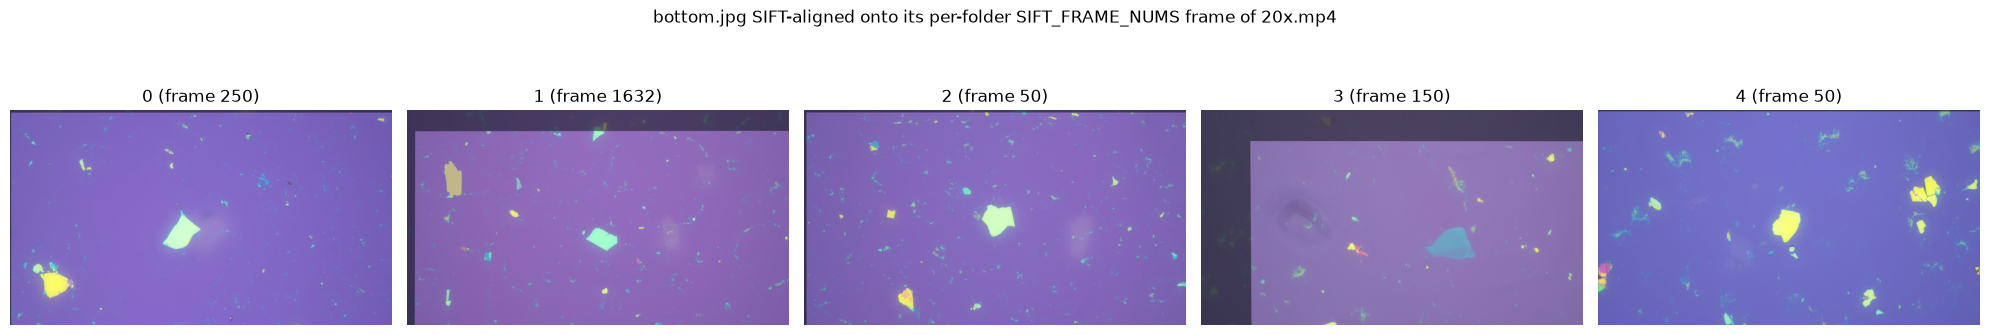

In [205]:
fig, axes = plt.subplots(1, len(episodes_all), figsize=(4 * len(episodes_all), 4))
for ax, ep in zip(axes, episodes_all):
    cap = cv2.VideoCapture(str(ep['video_path']))
    cap.set(cv2.CAP_PROP_POS_FRAMES, ep['sift_frame_num'])
    ok, ref_frame = cap.read()
    cap.release()
    M = np.hstack([ep['A'], ep['t'].reshape(2, 1)]).astype(np.float32)
    warped_bottom = cv2.warpAffine(ep['bottom_small'], M, (ep['vw'], ep['vh']))
    overlay = cv2.addWeighted(warped_bottom, 0.5, ref_frame, 0.5, 0.0)
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{ep['folder'].name} (frame {ep['sift_frame_num']})")
    ax.axis('off')
plt.suptitle(f'bottom.jpg SIFT-aligned onto its per-folder SIFT_FRAME_NUMS frame of {VIDEO_NAME}')
plt.tight_layout()
plt.show()


In [ ]:
_rng_demo = np.random.default_rng()
demo_ep = train_episodes[3]
demo_frame_idx = int(_rng_demo.integers(0, demo_ep['n_frames']))
demo_dx, demo_dy = _rng_demo.uniform(-RANDOM_OFFSET_PX_RANGE, RANDOM_OFFSET_PX_RANGE, size=2)

frame_i, frame_j, target_mm, ring_i = make_sample(demo_ep, demo_frame_idx, demo_dx, demo_dy)
target_full, mask = make_full_target(target_mm, ring_i, RING_NOT_FOUND)

diff_vis = np.abs(blur_for_diff(frame_j).astype(np.float32) - blur_for_diff(frame_i).astype(np.float32)).mean(axis=-1)
diff_vis_clipped = np.clip(diff_vis, 0, MAX_CLIP)
heat = cv2.applyColorMap((diff_vis_clipped / MAX_CLIP * 255).astype(np.uint8), cv2.COLORMAP_INFERNO)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(frame_i, cv2.COLOR_BGR2RGB)); axes[0].set_title('frame_i (random real video frame)'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(frame_j, cv2.COLOR_BGR2RGB)); axes[1].set_title(f'frame_j (synthetic top+bottom composite, top @ opacity {TOP_OPACITY})'); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)); axes[2].set_title(f'|blur diff| clipped at {MAX_CLIP}'); axes[2].axis('off')
target_str = '  '.join(f'{n}={target_full[i]:+.4f}{u}{"" if mask[i] else " (masked)"}' for i, (n, u) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)))
plt.suptitle(f'{demo_ep["folder"].name}  frame {demo_frame_idx}  offset=({demo_dx:+.1f}, {demo_dy:+.1f}) px (bottom.jpg native space)\n'
             f'target: {target_str}')
plt.tight_layout()
plt.show()


### Dataset
Each item is either:
- **synthetic** (probability `1 - REAL_PAIR_PROB`): a random `(folder, frame, offset)` synthesized via
  `make_sample` — `frame_i` real, `frame_j` a synthetic top+bottom composite. `Δx, Δy` come from the
  offset; `Δcx, Δcy, Δarea` come from `frame_i`'s real ring vs. `RING_NOT_FOUND` (`frame_j` never has
  a ring).
- **real** (probability `REAL_PAIR_PROB`): a random `(frame_i, frame_j)` pair from the same real
  episode, via `make_real_pair_sample` — mirrors `diff_pred.ipynb`'s `PairDisplacementDataset` exactly
  (`Δx, Δy` from stored motor position, `Δcx, Δcy, Δarea` from stored ring features).

Either way, `__getitem__` returns `(frame_i, frame_j, target, mask)`: `target` is `[Δx, Δy, Δcx, Δcy,
Δarea]` (raw units), `mask` is `1` for `Δx, Δy, Δarea` always, and `1` for `Δcx, Δcy` only when both
frames have a detected ring. `__len__` is a fixed virtual epoch size, not a real data count.

In [190]:
class SyntheticFlakeDisplacementDataset(Dataset):
    """Each item is either a synthetic top+bottom placement (make_sample, probability
    1 - REAL_PAIR_PROB) or a fully real (frame_i, frame_j) pair from the same episode
    (make_real_pair_sample, probability REAL_PAIR_PROB)."""

    def __init__(self, episodes, n_samples, offset_range=RANDOM_OFFSET_PX_RANGE, real_pair_prob=REAL_PAIR_PROB, seed=None):
        self.episodes = episodes
        self.n_samples = n_samples
        self.offset_range = offset_range
        self.real_pair_prob = real_pair_prob
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        ep = self.episodes[self.rng.integers(0, len(self.episodes))]

        if self.rng.random() < self.real_pair_prob:
            frame_i, frame_j, target, mask = make_real_pair_sample(ep, self.rng)
        else:
            frame_idx = int(self.rng.integers(0, ep['n_frames']))
            dx, dy = self.rng.uniform(-self.offset_range, self.offset_range, size=2)
            frame_i, frame_j, target_mm, ring_i = make_sample(ep, frame_idx, dx, dy)
            target, mask = make_full_target(target_mm, ring_i, RING_NOT_FOUND)

        frame_i_t = torch.from_numpy(frame_i[:, :, ::-1].copy()).permute(2, 0, 1)   # BGR -> RGB, (3, H, W) uint8
        frame_j_t = torch.from_numpy(frame_j[:, :, ::-1].copy()).permute(2, 0, 1)
        target_t  = torch.from_numpy(target)
        mask_t    = torch.from_numpy(mask)
        return frame_i_t, frame_j_t, target_t, mask_t


def _worker_init_fn(_worker_id):
    # each forked worker inherits the parent's rng state — reseed per worker so they don't all
    # generate the same stream of synthetic samples.
    info = torch.utils.data.get_worker_info()
    info.dataset.rng = np.random.default_rng(info.seed % (2 ** 32))


train_dataset = SyntheticFlakeDisplacementDataset(train_episodes, SAMPLES_PER_EPOCH)
train_loader  = DataLoader(train_dataset, batch_size=32, num_workers=4, drop_last=True, worker_init_fn=_worker_init_fn)
print(f'Train dataset size: {len(train_dataset):,} pairs/epoch ({REAL_PAIR_PROB:.0%} real, {1 - REAL_PAIR_PROB:.0%} synthetic)')

val_dataset = SyntheticFlakeDisplacementDataset(val_episodes, SAMPLES_PER_EPOCH_VAL, seed=1234)
val_loader  = DataLoader(val_dataset, batch_size=32, num_workers=0, drop_last=False)
print(f'Val dataset size  : {len(val_dataset):,} pairs')


Train dataset size: 5,000 pairs/epoch (25% real, 75% synthetic)
Val dataset size  : 1,000 pairs


### Sanity check — via the `Dataset` object
Same visualization as the demo cell above, but pulling a sample straight from `train_dataset` (so it
exercises the actual synthetic/real-pair mix and the returned `(frame_i, frame_j, target, mask)`
tensors) instead of calling `make_sample` directly.

In [ ]:
_sanity_idx = int(np.random.default_rng().integers(0, len(train_dataset)))
sanity_frame_i_t, sanity_frame_j_t, sanity_target_t, sanity_mask_t = train_dataset[_sanity_idx]

sanity_frame_i = sanity_frame_i_t.permute(1, 2, 0).numpy()   # already RGB, (H, W, 3) uint8
sanity_frame_j = sanity_frame_j_t.permute(1, 2, 0).numpy()
sanity_target  = sanity_target_t.numpy()
sanity_mask    = sanity_mask_t.numpy().astype(bool)

diff_vis = np.abs(blur_for_diff(sanity_frame_j).astype(np.float32) - blur_for_diff(sanity_frame_i).astype(np.float32)).mean(axis=-1)
diff_vis_clipped = np.clip(diff_vis, 0, MAX_CLIP)
heat = cv2.applyColorMap((diff_vis_clipped / MAX_CLIP * 255).astype(np.uint8), cv2.COLORMAP_INFERNO)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sanity_frame_i); axes[0].set_title('frame_i (Dataset item)'); axes[0].axis('off')
axes[1].imshow(sanity_frame_j); axes[1].set_title('frame_j (Dataset item)'); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)); axes[2].set_title(f'|blur diff| clipped at {MAX_CLIP}'); axes[2].axis('off')
target_str = '  '.join(f'{n}={sanity_target[i]:+.4f}{u}{"" if sanity_mask[i] else " (masked)"}' for i, (n, u) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)))
plt.suptitle(f'train_dataset[{_sanity_idx}]\ntarget: {target_str}')
plt.tight_layout()
plt.show()


## Model
Same blur+diff -> blank ViT -> MLP head architecture as `diff_pred.ipynb`, with the identical 5-dim
target `[Δx, Δy, Δcx, Δcy, Δarea]`. `Δcx, Δcy, Δarea` come from real Newton-ring features stored in
each folder's hdf5 (`frame_*_ring`) — masked out for `Δcx, Δcy` whenever either frame in a pair has
no detected ring (see `make_full_target`/`Dataset` above).


In [ ]:
EMB_DIM    = 192    # blank ViT hidden size == CLS token dim
TARGET_DIM = 5        # [Δx, Δy, Δcx, Δcy, Δarea] — same target shape as diff_pred.ipynb
                       # (AXIS_NAMES/AXIS_UNITS/BLUR_SIGMA are defined in the constants cell above)


def make_gaussian_kernel(sigma: float, device: str):
    """(1, 1, k, k) normalized 2D gaussian kernel, k = 2*round(3*sigma)+1."""
    if sigma <= 0:
        return None
    radius = max(1, int(round(3 * sigma)))
    coords = torch.arange(-radius, radius + 1, dtype=torch.float32, device=device)
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel_2d = torch.outer(g, g)
    kernel_2d = kernel_2d / kernel_2d.sum()
    return kernel_2d.view(1, 1, kernel_2d.shape[0], kernel_2d.shape[1])


def gaussian_blur(x: torch.Tensor, kernel: torch.Tensor | None) -> torch.Tensor:
    """(B, C, H, W) -> (B, C, H, W), blurred per-channel (depthwise conv, same padding)."""
    if kernel is None:
        return x
    c = x.shape[1]
    k = kernel.repeat(c, 1, 1, 1).to(dtype=x.dtype, device=x.device)
    pad = k.shape[-1] // 2
    return F.conv2d(x, k, padding=pad, groups=c)


_blur_kernel = make_gaussian_kernel(BLUR_SIGMA, device)

vit_cfg = ViTConfig(
    num_channels=3, image_size=IMG_SIZE, patch_size=16,
    hidden_size=EMB_DIM, num_hidden_layers=6,
    num_attention_heads=3, intermediate_size=768,
)
vit = ViTModel(vit_cfg, add_pooling_layer=False).to(device)
vit.train()   # randomly initialized ('blank'), fully trainable

n_vit = sum(p.numel() for p in vit.parameters())
print(f'ViT params (all trainable, randomly initialized): {n_vit:,}')


def to_float(x):
    """(B, 3, H, W) uint8 -> (B, 3, H, W) float32 [0,1] on device."""
    return x.to(device, dtype=torch.float32).div_(255.0)


def extract_embedding(frame_i_float, frame_j_float):
    """(B, 3, 224, 224) float32 [0,1] x2 -> (B, EMB_DIM) CLS token of the blank ViT run on
    the blurred difference image blur(frame_j) - blur(frame_i).
    """
    bi = gaussian_blur(frame_i_float, _blur_kernel)
    bj = gaussian_blur(frame_j_float, _blur_kernel)
    diff = bj - bi                                          # (B, 3, H, W)
    hidden = vit(diff, interpolate_pos_encoding=False).last_hidden_state
    return hidden[:, 0]                                      # (B, EMB_DIM) CLS token


class DisplacementHead(nn.Module):
    """CLS token -> small MLP -> (5,): [Δx, Δy, Δcx, Δcy, Δarea]. Kept under a 100k-param budget."""

    def __init__(self, emb_dim=EMB_DIM, target_dim=TARGET_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, 256),
            nn.SiLU(),
            nn.Linear(256, target_dim),
        )

    def forward(self, emb):
        return self.net(emb)


def sigreg_loss(emb, gamma=1.0, eps=1e-4):
    """Variance/'sigreg' hinge loss: penalize embedding dimensions whose batch-wise std
    falls below gamma, to prevent representation collapse while training the encoder.
    """
    std = torch.sqrt(emb.var(dim=0) + eps)
    return F.relu(gamma - std).mean()


head = DisplacementHead(emb_dim=EMB_DIM, target_dim=TARGET_DIM).to(device)
n_head = sum(p.numel() for p in head.parameters())
print(f'Head params (trainable): {n_head:,}')
assert n_head <= 100_000, f'head has {n_head:,} params, exceeds the 100k budget'

with torch.no_grad():
    _fi   = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=device)
    _fj   = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=device)
    _emb  = extract_embedding(_fi, _fj)
    _out  = head(_emb)
    print(f'Embedding shape : {_emb.shape}')   # expect (2, 192)
    print(f'Output shape    : {_out.shape}')   # expect (2, 5)


### Warm-start from `diff_pred_epoch_0040.pt`
Right after model instantiation, so training resumes from these weights — the head's output shape
matches diff_pred's exactly (5-dim), so both state dicts load unchanged.


In [ ]:
CKPT_PATH = CKPT_DIR / 'diff_pred_epoch_0040.pt'
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

vit.load_state_dict(ckpt['vit'])    # architecture is unchanged, so the full ViT loads as-is
head.load_state_dict(ckpt['head'])  # same 5-dim [Δx, Δy, Δcx, Δcy, Δarea] output shape, loads as-is

STARTING_EPOCH = ckpt['epoch']
print(f'Warm-started vit + head from {CKPT_PATH.name} (epoch {STARTING_EPOCH}).')


### Target normalization
Recomputed from actual `train_dataset` samples (mirroring the real synthetic/real-pair mix,
including masked-out Δcx/Δcy) rather than closed-form offset math, since the target now includes
real ring-derived Δcx/Δcy/Δarea alongside the synthetic Δx/Δy offsets.

In [ ]:
_stats_dataset = SyntheticFlakeDisplacementDataset(train_episodes, n_samples=6000, seed=42)

_samples_xy_area, _samples_cxcy = [], []
for i in range(len(_stats_dataset)):
    _, _, target, mask = _stats_dataset[i]
    target, mask = target.numpy(), mask.numpy().astype(bool)
    _samples_xy_area.append(target[[0, 1, 4]])   # Δx, Δy, Δarea — always valid
    if mask[2]:                                    # Δcx, Δcy valid only when both frames have a ring
        _samples_cxcy.append(target[[2, 3]])

_samples_xy_area = np.stack(_samples_xy_area)   # (N, 3)
_samples_cxcy    = np.stack(_samples_cxcy) if _samples_cxcy else np.zeros((1, 2), dtype=np.float32)

_mean_xy_area = _samples_xy_area.mean(0)
_std_xy_area  = _samples_xy_area.std(0).clip(min=1e-3)
_mean_cxcy    = _samples_cxcy.mean(0)
_std_cxcy     = _samples_cxcy.std(0).clip(min=1e-3)

# Reassemble into (5,) [Δx, Δy, Δcx, Δcy, Δarea] order.
delta_mean = torch.from_numpy(np.concatenate([_mean_xy_area[:2], _mean_cxcy, _mean_xy_area[2:]]).astype(np.float32)).to(device)
delta_std  = torch.from_numpy(np.concatenate([_std_xy_area[:2],  _std_cxcy,  _std_xy_area[2:]]).astype(np.float32)).to(device)

print(f'Target stats from {len(_stats_dataset):,} train_dataset samples ({len(_samples_cxcy):,} with a valid ring pair):')
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    print(f'  {name}: mean={delta_mean[i]:.4f}  std={delta_std[i]:.4f} {unit}')


def normalize_target(target):
    """(B, 5) raw [Δx, Δy, Δcx, Δcy, Δarea] -> (B, 5) z-scored."""
    return (target - delta_mean) / delta_std


def denormalize_target(pred):
    """(B, 5) z-scored -> (B, 5) raw [Δx, Δy, Δcx, Δcy, Δarea]."""
    return pred * delta_std + delta_mean


## Training
The whole ViT is trainable, optimized jointly with the head — resumes from `STARTING_EPOCH`.

In [ ]:
NUM_EPOCHS     = STARTING_EPOCH + 50   # train 50 more epochs from the warm-started checkpoint
SIGREG_WEIGHT  = 0.05
SIGREG_GAMMA   = 1.0

optimizer = torch.optim.AdamW([
    {'params': vit.parameters(),  'lr': 1e-4},
    {'params': head.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - STARTING_EPOCH)


def masked_huber(pred, target_norm, mask, delta=1.0):
    """Elementwise Huber loss, masked and averaged only over valid (mask==1) entries."""
    elementwise = F.huber_loss(pred, target_norm, delta=delta, reduction='none')
    return (elementwise * mask).sum() / mask.sum().clamp(min=1.0)


def masked_abs_error_sum(pred_raw, target, mask):
    """Returns (sum of |error| per axis, count of valid entries per axis) for masked accumulation."""
    abs_err = (pred_raw - target).abs() * mask
    return abs_err.sum(dim=0).cpu(), mask.sum(dim=0).cpu()


def run_validation():
    vit.eval(); head.eval()
    losses = []
    err_sum, err_count = torch.zeros(TARGET_DIM), torch.zeros(TARGET_DIM)
    with torch.no_grad():
        for frame_i, frame_j, target, mask in val_loader:
            frame_i, frame_j = to_float(frame_i), to_float(frame_j)
            target = target.to(device)
            mask   = mask.to(device)
            target_norm = normalize_target(target)

            emb  = extract_embedding(frame_i, frame_j)
            pred = head(emb)
            loss = masked_huber(pred, target_norm, mask)

            pred_raw = denormalize_target(pred)
            e_sum, e_cnt = masked_abs_error_sum(pred_raw, target, mask)
            err_sum += e_sum; err_count += e_cnt
            losses.append(loss.item())
    vit.train(); head.train()
    return float(np.mean(losses)), err_sum / err_count.clamp(min=1.0)


vit.train()
head.train()

for epoch in range(STARTING_EPOCH, NUM_EPOCHS):
    losses, sigreg_losses = [], []
    train_err_sum, train_err_count = torch.zeros(TARGET_DIM), torch.zeros(TARGET_DIM)

    for frame_i, frame_j, target, mask in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=False):
        frame_i, frame_j = to_float(frame_i), to_float(frame_j)
        target      = target.to(device)
        mask        = mask.to(device)
        target_norm = normalize_target(target)

        emb  = extract_embedding(frame_i, frame_j)
        pred = head(emb)                                       # (B, 5) normalised
        h    = masked_huber(pred, target_norm, mask)
        sreg = sigreg_loss(emb, gamma=SIGREG_GAMMA)
        loss = h + SIGREG_WEIGHT * sreg

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(vit.parameters()) + list(head.parameters()), max_norm=5.0)
        optimizer.step()

        pred_raw = denormalize_target(pred.detach())
        e_sum, e_cnt = masked_abs_error_sum(pred_raw, target, mask)
        train_err_sum += e_sum; train_err_count += e_cnt
        losses.append(h.item())
        sigreg_losses.append(sreg.item())

    scheduler.step()
    val_loss, val_abs_err = run_validation()
    train_abs_err = train_err_sum / train_err_count.clamp(min=1.0)
    train_err_str = '  '.join(f'{n}={train_abs_err[i]:.4f}{u}' for i, (n, u) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)))
    val_err_str   = '  '.join(f'{n}={val_abs_err[i]:.4f}{u}' for i, (n, u) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)))
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}  '
          f'train_loss={np.mean(losses):.4f}  sigreg={np.mean(sigreg_losses):.4f}  '
          f'lr={scheduler.get_last_lr()[-1]:.2e}')
    print(f'  train|err|: {train_err_str}')
    print(f'  val_loss={val_loss:.4f}  val|err|: {val_err_str}')

    if (epoch + 1) % 10 == 0 or epoch + 1 == NUM_EPOCHS:
        torch.save({
            'epoch': epoch + 1,
            'vit': vit.state_dict(),
            'head': head.state_dict(),
            'delta_mean': delta_mean.cpu(),
            'delta_std': delta_std.cpu(),
        }, CKPT_DIR / f'diff_pred_20x_epoch_{epoch+1:04d}.pt')

## Testing
### Per-axis error distribution — 100 random synthetic samples
Same format as `diff_pred.ipynb`'s Per-axis error distribution cell: generate a random displacement
and a random frame (from the held-out validation folder), run the model, and compare prediction to
ground truth — repeated 100 times.

In [ ]:
N_TEST = 100
_rng_test = np.random.default_rng(7)
test_ep = val_episodes[0]

test_preds, test_gt, test_mask = [], [], []
vit.eval()
head.eval()
with torch.no_grad():
    for _ in tqdm(range(N_TEST), desc='Testing'):
        frame_idx = int(_rng_test.integers(0, test_ep['n_frames']))
        dx, dy = _rng_test.uniform(-RANDOM_OFFSET_PX_RANGE, RANDOM_OFFSET_PX_RANGE, size=2)
        frame_i, frame_j, target_mm, ring_i = make_sample(test_ep, frame_idx, dx, dy)
        target, mask = make_full_target(target_mm, ring_i, RING_NOT_FOUND)

        fi_t = to_float(torch.from_numpy(frame_i[:, :, ::-1].copy()).permute(2, 0, 1).unsqueeze(0))
        fj_t = to_float(torch.from_numpy(frame_j[:, :, ::-1].copy()).permute(2, 0, 1).unsqueeze(0))
        emb = extract_embedding(fi_t, fj_t)
        pred_raw = denormalize_target(head(emb)).squeeze(0).cpu().numpy()

        test_preds.append(pred_raw)
        test_gt.append(target)
        test_mask.append(mask)
vit.train()
head.train()

test_preds = np.stack(test_preds)
test_gt    = np.stack(test_gt)
test_mask  = np.stack(test_mask).astype(bool)
errors     = test_preds - test_gt

# frame_j is always a synthetic composite here (make_sample, not make_real_pair_sample), so it never
# has a real ring — Δcx/Δcy are masked out (mask=0) for every one of these samples, only Δx/Δy/Δarea
# are actually evaluated.
print(f'Per-axis MAE — {N_TEST} random synthetic samples from {test_ep["folder"].name}:')
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = test_mask[:, i]
    if valid.sum() == 0:
        print(f'  {name}: no valid samples (always masked)')
        continue
    mae  = np.abs(errors[valid, i]).mean()
    rmse = np.sqrt((errors[valid, i] ** 2).mean())
    print(f'  {name}: MAE={mae:.3f} {unit}   RMSE={rmse:.3f} {unit}   (n={valid.sum()}/{len(valid)})')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = test_mask[:, i]
    ax = axes[i]
    if valid.sum() == 0:
        ax.set_title(f'Δ{name} (always masked)')
        ax.axis('off')
        continue
    gt = test_gt[valid, i]
    pr = test_preds[valid, i]
    lim = max(np.abs(gt).max(), np.abs(pr).max()) * 1.05
    ax.scatter(gt, pr, s=8, alpha=0.6, color='steelblue')
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.2, label='ideal')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'GT Δ{name} ({unit})'); ax.set_ylabel(f'Pred Δ{name} ({unit})')
    ax.set_title(f'Δ{name}  MAE={np.abs(errors[valid, i]).mean():.3f} {unit}')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Per-axis error distribution — `train_loader` and `val_loader` (real + synthetic mix)
Same as above, but sweeping the full `train_loader` (below) and `val_loader` (next cell) — each is
the actual 25% real / 75% synthetic mix used in training, rather than only synthetic samples, so
these are the only cells that can evaluate `Δcx, Δcy` at all (masked out for every synthetic pair).
Mirrors `diff_pred.ipynb`'s own `Per-axis error distribution` cell exactly (full loader sweep), once
for each loader.

In [ ]:
train_preds, train_gt, train_mask = [], [], []

vit.eval()
head.eval()
with torch.no_grad():
    for frame_i, frame_j, target, mask in tqdm(train_loader, desc='Evaluating (train)'):
        frame_i = to_float(frame_i.to(device))
        frame_j = to_float(frame_j.to(device))
        emb = extract_embedding(frame_i, frame_j)
        pred_norm = head(emb)
        pred_raw  = denormalize_target(pred_norm).cpu()
        train_preds.append(pred_raw)
        train_gt.append(target)
        train_mask.append(mask)
vit.train()
head.train()

train_preds = torch.cat(train_preds).numpy()
train_gt    = torch.cat(train_gt).numpy()
train_mask  = torch.cat(train_mask).numpy().astype(bool)
errors      = train_preds - train_gt

print(f'Per-axis MAE — {len(train_preds):,} train_loader pairs (Δcx/Δcy computed only over pairs with a ring in both frames):')
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = train_mask[:, i]
    if valid.sum() == 0:
        print(f'  {name}: no valid samples')
        continue
    mae  = np.abs(errors[valid, i]).mean()
    rmse = np.sqrt((errors[valid, i] ** 2).mean())
    print(f'  {name}: MAE={mae:.3f} {unit}   RMSE={rmse:.3f} {unit}   (n={valid.sum()}/{len(valid)})')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = train_mask[:, i]
    ax = axes[i]
    if valid.sum() == 0:
        ax.set_title(f'Δ{name} (no valid samples)')
        ax.axis('off')
        continue
    gt = train_gt[valid, i]
    pr = train_preds[valid, i]
    lim = max(np.abs(gt).max(), np.abs(pr).max()) * 1.05
    ax.scatter(gt, pr, s=2, alpha=0.3, color='steelblue', rasterized=True)
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.2, label='ideal')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'GT Δ{name} ({unit})'); ax.set_ylabel(f'Pred Δ{name} ({unit})')
    ax.set_title(f'Δ{name}  MAE={np.abs(errors[valid, i]).mean():.3f} {unit}')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
plt.suptitle('train_loader')
plt.tight_layout()
plt.show()

In [ ]:
val_preds, val_gt, val_mask = [], [], []

vit.eval()
head.eval()
with torch.no_grad():
    for frame_i, frame_j, target, mask in tqdm(val_loader, desc='Evaluating (val)'):
        frame_i = to_float(frame_i.to(device))
        frame_j = to_float(frame_j.to(device))
        emb = extract_embedding(frame_i, frame_j)
        pred_norm = head(emb)
        pred_raw  = denormalize_target(pred_norm).cpu()
        val_preds.append(pred_raw)
        val_gt.append(target)
        val_mask.append(mask)
vit.train()
head.train()

val_preds = torch.cat(val_preds).numpy()
val_gt    = torch.cat(val_gt).numpy()
val_mask  = torch.cat(val_mask).numpy().astype(bool)
errors    = val_preds - val_gt

print(f'Per-axis MAE — {len(val_preds):,} val_loader pairs (Δcx/Δcy computed only over pairs with a ring in both frames):')
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = val_mask[:, i]
    if valid.sum() == 0:
        print(f'  {name}: no valid samples')
        continue
    mae  = np.abs(errors[valid, i]).mean()
    rmse = np.sqrt((errors[valid, i] ** 2).mean())
    print(f'  {name}: MAE={mae:.3f} {unit}   RMSE={rmse:.3f} {unit}   (n={valid.sum()}/{len(valid)})')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = val_mask[:, i]
    ax = axes[i]
    if valid.sum() == 0:
        ax.set_title(f'Δ{name} (no valid samples)')
        ax.axis('off')
        continue
    gt = val_gt[valid, i]
    pr = val_preds[valid, i]
    lim = max(np.abs(gt).max(), np.abs(pr).max()) * 1.05
    ax.scatter(gt, pr, s=2, alpha=0.3, color='steelblue', rasterized=True)
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.2, label='ideal')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'GT Δ{name} ({unit})'); ax.set_ylabel(f'Pred Δ{name} ({unit})')
    ax.set_title(f'Δ{name}  MAE={np.abs(errors[valid, i]).mean():.3f} {unit}')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
plt.suptitle('val_loader')
plt.tight_layout()
plt.show()

_rng_vis = np.random.default_rng()
vis_ep = val_episodes[0]
vis_frame_idx = int(_rng_vis.integers(0, vis_ep['n_frames']))
vis_dx, vis_dy = _rng_vis.uniform(-RANDOM_OFFSET_PX_RANGE, RANDOM_OFFSET_PX_RANGE, size=2)

vis_frame_i, vis_frame_j, vis_target_mm, vis_ring_i = make_sample(vis_ep, vis_frame_idx, vis_dx, vis_dy)
vis_target_full, vis_mask = make_full_target(vis_target_mm, vis_ring_i, RING_NOT_FOUND)

vit.eval()
head.eval()
with torch.no_grad():
    fi_t = torch.from_numpy(vis_frame_i[:, :, ::-1].copy()).permute(2, 0, 1).unsqueeze(0)
    fj_t = torch.from_numpy(vis_frame_j[:, :, ::-1].copy()).permute(2, 0, 1).unsqueeze(0)
    emb  = extract_embedding(to_float(fi_t), to_float(fj_t))
    vis_pred_raw = denormalize_target(head(emb)).squeeze(0).cpu().numpy()
vit.train()
head.train()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(vis_frame_i, cv2.COLOR_BGR2RGB)); axes[0].set_title('video frame (source)'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(vis_frame_j, cv2.COLOR_BGR2RGB)); axes[1].set_title(f'constructed overlay (top @ opacity {TOP_OPACITY})'); axes[1].axis('off')

gt_str   = '  '.join(f'{n}={vis_target_full[i]:+.4f}{u}{"" if vis_mask[i] else " (masked)"}' for i, (n, u) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)))
pred_str = '  '.join(f'{n}={vis_pred_raw[i]:+.4f}{u}' for i, (n, u) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)))
plt.suptitle(f'{vis_ep["folder"].name}  frame {vis_frame_idx}\nGT:   {gt_str}\nPred: {pred_str}', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
_rng_vis = np.random.default_rng(123)
vis_ep = val_episodes[0]
vis_frame_idx = int(_rng_vis.integers(0, vis_ep['n_frames']))
vis_dx, vis_dy = _rng_vis.uniform(-RANDOM_OFFSET_PX_RANGE, RANDOM_OFFSET_PX_RANGE, size=2)

vis_frame_i, vis_frame_j, vis_target_mm, vis_ring_i = make_sample(vis_ep, vis_frame_idx, vis_dx, vis_dy)
vis_target_full, vis_mask = make_full_target(vis_target_mm, vis_ring_i, RING_NOT_FOUND)

vit.eval()
head.eval()
with torch.no_grad():
    fi_t = torch.from_numpy(vis_frame_i[:, :, ::-1].copy()).permute(2, 0, 1).unsqueeze(0)
    fj_t = torch.from_numpy(vis_frame_j[:, :, ::-1].copy()).permute(2, 0, 1).unsqueeze(0)
    emb  = extract_embedding(to_float(fi_t), to_float(fj_t))
    vis_pred_raw = denormalize_target(head(emb)).squeeze(0).cpu().numpy()
vit.train()
head.train()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(vis_frame_i, cv2.COLOR_BGR2RGB)); axes[0].set_title('video frame (source)'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(vis_frame_j, cv2.COLOR_BGR2RGB)); axes[1].set_title(f'constructed overlay (top @ opacity {TOP_OPACITY})'); axes[1].axis('off')

gt_str   = '  '.join(f'{n}={vis_target_full[i]:+.4f}{u}{"" if vis_mask[i] else " (masked)"}' for i, (n, u) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)))
pred_str = '  '.join(f'{n}={vis_pred_raw[i]:+.4f}{u}' for i, (n, u) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)))
plt.suptitle(f'{vis_ep["folder"].name}  frame {vis_frame_idx}\nGT:   {gt_str}\nPred: {pred_str}', fontsize=10)
plt.tight_layout()
plt.show()